## 1. Install & Import

In [ ]:
!pip install lightgbm xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
print('✅ Done')

✅ Done


## 2. Load Data

In [ ]:
# 1. เชื่อมต่อ Google Drive เพื่อดึงข้อมูลมาใช้
from google.colab import drive
drive.mount('/content/drive')

# 2. กำหนดที่อยู่ไฟล์ (Path) ของข้อมูล Train, Test และไฟล์ตัวอย่างการส่งคำตอบ
TRAIN_PATH = '/content/drive/MyDrive/super-ai-engineer-season-6-heart-disease-2569/train.csv'
TEST_PATH  = '/content/drive/MyDrive/super-ai-engineer-season-6-heart-disease-2569/test.csv'
SUB_PATH   = '/content/drive/MyDrive/super-ai-engineer-season-6-heart-disease-2569/sample_submission.csv'

# 3. อ่านไฟล์ CSV เข้ามาเป็นตาราง (DataFrame)
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

# แสดงขนาดของข้อมูลและตัวอย่าง 3 แถวแรก
print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'Sample sub  : {sample_sub.shape}')
display(train.head(3))

## 3. Diagnose: ตรวจสอบ Target Column ก่อนเสมอ

In [ ]:
TARGET = 'History of HeartDisease or Attack'

# ── ดู unique values ของ target จริงๆ ────────────────────────────────────────
print('=== Target unique values ===')
print(train[TARGET].value_counts())
print('\nDtype:', train[TARGET].dtype)
print('\nSample values:', train[TARGET].unique()[:10])

# ── Class imbalance ratio ─────────────────────────────────────────────────────
vc = train[TARGET].value_counts()
print(f'\n⚠️  Imbalance ratio: {vc.max() / vc.min():.1f}x')
print('→ ยิ่ง ratio สูง ยิ่งต้องการ threshold ต่ำ และ class_weight สูง')

=== Target unique values ===
History of HeartDisease or Attack
No     203322
Yes     18068
Name: count, dtype: int64

Dtype: object

Sample values: ['No' 'Yes']

⚠️  Imbalance ratio: 11.3x
→ ยิ่ง ratio สูง ยิ่งต้องการ threshold ต่ำ และ class_weight สูง


In [ ]:
# ── Drop rows where target is NaN ──────────────────────────────────────────
TARGET = 'History of HeartDisease or Attack'

n_before  = len(train)
train      = train.dropna(subset=[TARGET]).copy()
n_after   = len(train)

print(f'Dropped : {n_before - n_after:,} rows')
print(f'Remaining: {n_after:,} rows')
print(train[TARGET].value_counts())

# ── Recompute scale_pos_weight ─────────────────────────────────────────────
n_no  = (train[TARGET] == 'No').sum()
n_yes = (train[TARGET] == 'Yes').sum()
scale_pos_weight = n_no / n_yes

print(f'\nscale_pos_weight = {scale_pos_weight:.2f}')

Dropped : 1,694 rows
Remaining: 221,390 rows
History of HeartDisease or Attack
No     203322
Yes     18068
Name: count, dtype: int64

scale_pos_weight = 11.25


In [ ]:
# ── ดู test ID format ─────────────────────────────────────────────────────────
print('Test ID sample:')
print(test.iloc[:3, :2])   # ID + first feature
print('\nSample submission:')
print(sample_sub.head(3))

Test ID sample:
            ID High Blood Pressure
0  test_000001                 Yes
1  test_000002                 Yes
2  test_000003                 Yes

Sample submission:
            ID History of HeartDisease or Attack
0  test_000001                                No
1  test_000002                                No
2  test_000003                                No


## 4. Preprocessing

In [ ]:
def preprocess(train_df, test_df, target_col):
    """ ฟังก์ชันสำหรับเตรียมข้อมูลให้พร้อมก่อนส่งให้ AI เรียนรู้ """
    train_proc = train_df.copy()
    test_proc  = test_df.copy()

    # แยก ID ไว้สำหรับใช้ตอนส่งคำตอบ
    id_col   = 'ID'
    test_ids = test_proc[id_col].values

    # เปลี่ยนคำตอบ (Target) จาก 'Yes'/'No' ให้เป็นตัวเลข 1 กับ 0
    y_raw = train_proc[target_col]
    if y_raw.dtype == object:
        y = y_raw.map({'Yes': 1, 'No': 0, 'YES': 1, 'NO': 0, 'yes': 1, 'no': 0})
    else:
        y = y_raw.astype(int)

    # ลบคอลัมน์ที่ไม่ใช่ฟีเจอร์ในการทำนายออก (เช่น ID และตัวคำตอบเอง)
    train_proc = train_proc.drop(columns=[id_col, target_col], errors='ignore')
    test_proc  = test_proc.drop(columns=[id_col], errors='ignore')

    n_train  = len(train_proc)
    combined = pd.concat([train_proc, test_proc], axis=0, ignore_index=True)

    # เปลี่ยนข้อมูลที่เป็นตัวหนังสือ (เช่น เพศ, ประวัติการสูบบุหรี่) ให้เป็นตัวเลข
    binary_map = {'Yes': 1, 'No': 0}
    for col in combined.select_dtypes(include='object').columns:
        uniq = set(combined[col].dropna().unique())
        if uniq.issubset(set(binary_map.keys())):
            combined[col] = combined[col].map(binary_map)
        else:
            le = LabelEncoder()
            combined[col] = le.fit_transform(combined[col].astype(str))

    # เติมค่าว่างด้วยค่ากลาง (Median) เพื่อไม่ให้โมเดล Error
    for col in combined.columns:
        if combined[col].isnull().any():
            combined[col].fillna(combined[col].median(), inplace=True)

    # แยกข้อมูลกลับเป็นชุด Train (ไว้ฝึก) และ Test (ไว้ส่งคำตอบ)
    X_train = combined.iloc[:n_train].reset_index(drop=True).astype(float)
    X_test  = combined.iloc[n_train:].reset_index(drop=True).astype(float)

    return X_train, y.reset_index(drop=True), X_test, test_ids

X_train, y_train, X_test, test_ids = preprocess(train, test, TARGET)

Target values before encoding: ['No' 'Yes']
✅ Target encoded — 1 (Yes): 18068  |  0 (No): 203322

X_train: (221390, 18)  |  X_test: (74361, 18)


## 5. Compute Class Weights

In [ ]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'n_neg (No) : {n_neg}')
print(f'n_pos (Yes): {n_pos}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')
print(f'\n→ โมเดลจะให้น้ำหนัก class Yes สูงกว่า {scale_pos_weight:.1f}x')

n_neg (No) : 203322
n_pos (Yes): 18068
scale_pos_weight: 11.25

→ โมเดลจะให้น้ำหนัก class Yes สูงกว่า 11.3x


## 6. F2 Utility Functions

In [ ]:
def f2_weighted(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2, average='weighted')

def find_best_threshold(y_true, y_proba, beta=2, steps=200):
    """Grid search threshold 0.05–0.95 → maximise F2 weighted."""
    thresholds = np.linspace(0.05, 0.95, steps)
    scores = [f2_weighted(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(scores))
    best_t   = thresholds[best_idx]
    best_s   = scores[best_idx]

    # Plot
    plt.figure(figsize=(9, 3))
    plt.plot(thresholds, scores, color='royalblue')
    plt.axvline(best_t, color='red', linestyle='--', label=f'Best={best_t:.3f} (F2={best_s:.5f})')
    plt.xlabel('Threshold')
    plt.ylabel('F2 Score (weighted)')
    plt.title('F2 Score vs Classification Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'✅ Best threshold: {best_t:.4f}  →  F2 = {best_s:.5f}')
    return best_t, best_s

print('✅ F2 utils ready')

✅ F2 utils ready


## 7. Train Models (5-Fold CV + OOF)

In [ ]:
# ── Model Definitions ─────────────────────────────────────────────────────────
lgbm_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 10,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.05,
    reg_lambda        = 0.05,
    scale_pos_weight  = scale_pos_weight,  # KEY: ให้น้ำหนัก Yes
    class_weight      = 'balanced',
    random_state      = 42,
    verbosity         = -1,
    n_jobs            = -1,
)

xgb_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.05,
    reg_lambda        = 0.5,
    scale_pos_weight  = scale_pos_weight,  # KEY
    eval_metric       = 'logloss',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
)

rf_params = dict(
    n_estimators     = 500,
    max_depth        = 12,
    min_samples_leaf = 5,
    class_weight     = {0: 1, 1: scale_pos_weight},  # KEY
    random_state     = 42,
    n_jobs           = -1,
)

models = {
    'LightGBM'    : lgb.LGBMClassifier(**lgbm_params),
    'XGBoost'     : xgb.XGBClassifier(**xgb_params),
    'RandomForest': RandomForestClassifier(**rf_params),
}

print('✅ Models defined')

✅ Models defined


In [ ]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
smote = SMOTE(random_state=42)

oof_preds  = {name: np.zeros(len(X_train)) for name in models}
test_preds = {name: np.zeros(len(X_test))  for name in models}
cv_f2      = {name: [] for name in models}

for model_name, model in models.items():
    print(f'\n{'─'*50}')
    print(f'  {model_name}')
    print('─'*50)

    for fold, (trn_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr  = X_train.iloc[trn_idx]
        y_tr  = y_train.iloc[trn_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        # SMOTE เฉพาะ training split
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

        model.fit(X_tr_sm, y_tr_sm)

        val_proba = model.predict_proba(X_val)[:, 1]
        oof_preds[model_name][val_idx] = val_proba
        test_preds[model_name] += model.predict_proba(X_test)[:, 1] / N_FOLDS

        # F2 at threshold=0.3 (lower than 0.5 because F2 prefers Recall)
        val_pred = (val_proba >= 0.3).astype(int)
        f2 = f2_weighted(y_val, val_pred)
        cv_f2[model_name].append(f2)
        print(f'  Fold {fold}: F2@0.3 = {f2:.5f}')

    m = np.mean(cv_f2[model_name])
    s = np.std(cv_f2[model_name])
    print(f'  ➜ Mean F2: {m:.5f} ± {s:.5f}')


──────────────────────────────────────────────────
  LightGBM
──────────────────────────────────────────────────
  Fold 1: F2@0.3 = 0.67193
  Fold 2: F2@0.3 = 0.67873
  Fold 3: F2@0.3 = 0.67596
  Fold 4: F2@0.3 = 0.67285
  Fold 5: F2@0.3 = 0.67687
  ➜ Mean F2: 0.67527 ± 0.00253

──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
  Fold 1: F2@0.3 = 0.64970
  Fold 2: F2@0.3 = 0.65151
  Fold 3: F2@0.3 = 0.65149
  Fold 4: F2@0.3 = 0.64842
  Fold 5: F2@0.3 = 0.65054
  ➜ Mean F2: 0.65033 ± 0.00117

──────────────────────────────────────────────────
  RandomForest
──────────────────────────────────────────────────
  Fold 1: F2@0.3 = 0.51595
  Fold 2: F2@0.3 = 0.52700
  Fold 3: F2@0.3 = 0.51683
  Fold 4: F2@0.3 = 0.52545
  Fold 5: F2@0.3 = 0.51568
  ➜ Mean F2: 0.52018 ± 0.00497


## 8. 🔧 Find Best Threshold per Model


[LightGBM]


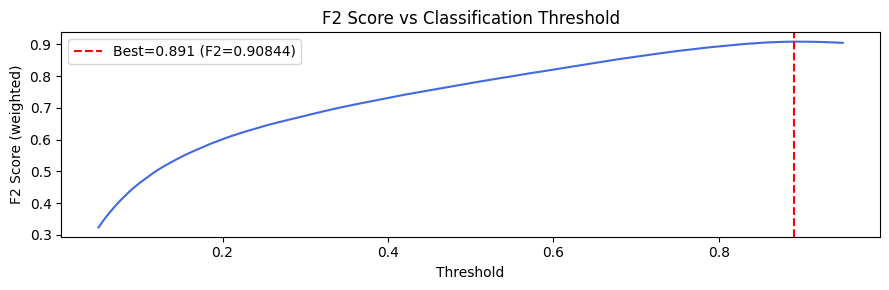

✅ Best threshold: 0.8912  →  F2 = 0.90844
              precision    recall  f1-score   support

          No       0.93      0.98      0.96    203322
         Yes       0.46      0.19      0.27     18068

    accuracy                           0.92    221390
   macro avg       0.70      0.58      0.61    221390
weighted avg       0.89      0.92      0.90    221390


[XGBoost]


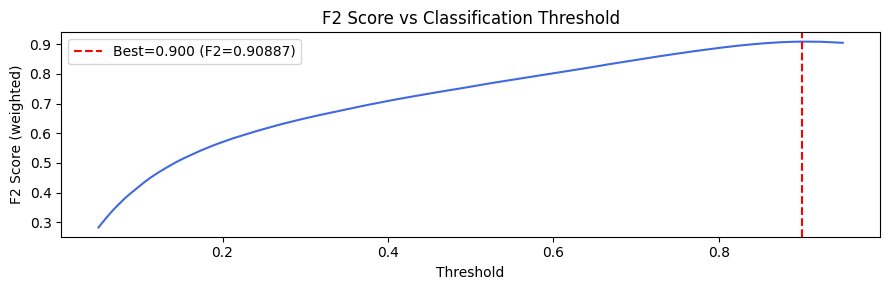

✅ Best threshold: 0.9003  →  F2 = 0.90887
              precision    recall  f1-score   support

          No       0.93      0.98      0.96    203322
         Yes       0.47      0.18      0.26     18068

    accuracy                           0.92    221390
   macro avg       0.70      0.58      0.61    221390
weighted avg       0.89      0.92      0.90    221390


[RandomForest]


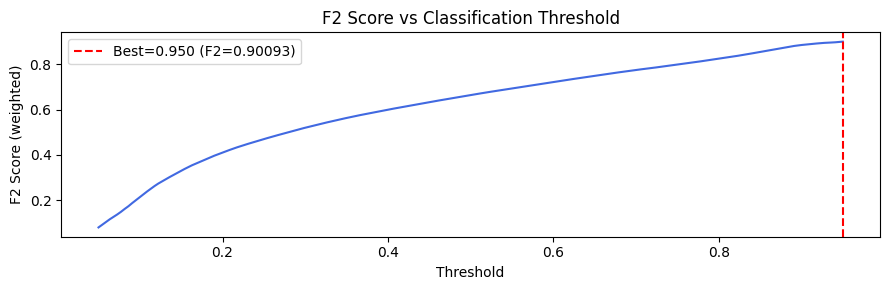

✅ Best threshold: 0.9500  →  F2 = 0.90093
              precision    recall  f1-score   support

          No       0.93      0.97      0.95    203322
         Yes       0.37      0.22      0.28     18068

    accuracy                           0.91    221390
   macro avg       0.65      0.60      0.61    221390
weighted avg       0.89      0.91      0.89    221390



In [ ]:
best_t_per_model = {}

for model_name in models:
    print(f'\n[{model_name}]')
    t, s = find_best_threshold(y_train, oof_preds[model_name])
    best_t_per_model[model_name] = t
    y_p = (oof_preds[model_name] >= t).astype(int)
    print(classification_report(y_train, y_p, target_names=['No','Yes']))

## 9. Ensemble

Ensemble weights: {'LightGBM': '0.366', 'XGBoost': '0.352', 'RandomForest': '0.282'}

[Ensemble OOF]


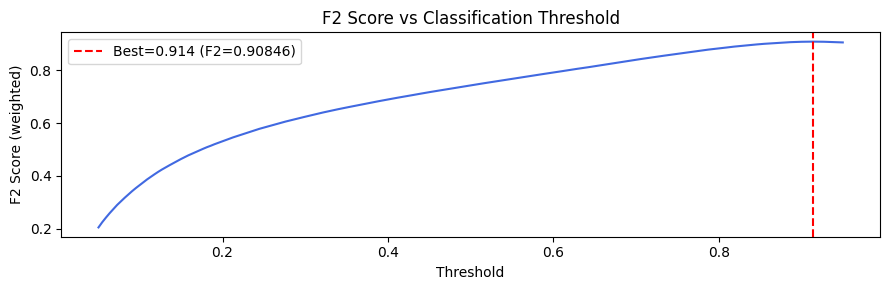

✅ Best threshold: 0.9138  →  F2 = 0.90846
              precision    recall  f1-score   support

          No       0.93      0.98      0.96    203322
         Yes       0.47      0.16      0.24     18068

    accuracy                           0.92    221390
   macro avg       0.70      0.57      0.60    221390
weighted avg       0.89      0.92      0.90    221390



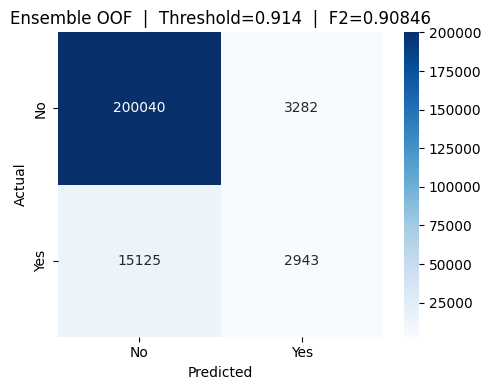

In [ ]:
# Weighted average (weight = mean CV F2)
raw_weights = {k: np.mean(v) for k, v in cv_f2.items()}
total_w     = sum(raw_weights.values())
weights     = {k: v / total_w for k, v in raw_weights.items()}
print('Ensemble weights:', {k: f'{v:.3f}' for k, v in weights.items()})

oof_ens  = sum(oof_preds[n]  * w for n, w in weights.items())
test_ens = sum(test_preds[n] * w for n, w in weights.items())

print('\n[Ensemble OOF]')
best_t_ens, best_f2_ens = find_best_threshold(y_train, oof_ens)

y_ens_pred = (oof_ens >= best_t_ens).astype(int)
print(classification_report(y_train, y_ens_pred, target_names=['No','Yes']))

# Confusion matrix
cm = confusion_matrix(y_train, y_ens_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title(f'Ensemble OOF  |  Threshold={best_t_ens:.3f}  |  F2={best_f2_ens:.5f}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

## 10. Probability Distribution Check
> ถ้าโมเดลดี: กราฟ Yes และ No ควรแยกจากกัน

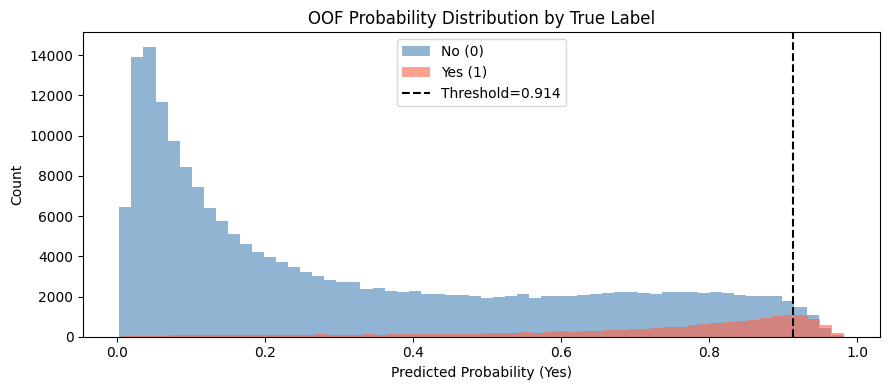

OOF Proba stats for Yes class:
count    18068.000000
mean         0.722783
std          0.219748
min          0.007628
25%          0.620090
50%          0.797849
75%          0.889630
max          0.982055
dtype: float64

OOF Proba stats for No class:
count    203322.000000
mean          0.320028
std           0.281250
min           0.003738
25%           0.075767
50%           0.213304
75%           0.546213
max           0.980572
dtype: float64


In [ ]:
plt.figure(figsize=(9, 4))
plt.hist(oof_ens[y_train == 0], bins=60, alpha=0.6, label='No (0)',  color='steelblue')
plt.hist(oof_ens[y_train == 1], bins=60, alpha=0.6, label='Yes (1)', color='tomato')
plt.axvline(best_t_ens, color='black', linestyle='--', label=f'Threshold={best_t_ens:.3f}')
plt.xlabel('Predicted Probability (Yes)')
plt.ylabel('Count')
plt.title('OOF Probability Distribution by True Label')
plt.legend()
plt.tight_layout()
plt.show()

print('OOF Proba stats for Yes class:')
print(pd.Series(oof_ens[y_train == 1]).describe())
print('\nOOF Proba stats for No class:')
print(pd.Series(oof_ens[y_train == 0]).describe())

## 11. Generate Submissions
> สร้าง 3 versions: best threshold, aggressive (lower), conservative

In [ ]:
def make_submission(test_proba, threshold, filename, test_ids):
    y_pred  = (test_proba >= threshold).astype(int)
    labels  = pd.Series(y_pred).map({1: 'Yes', 0: 'No'}).values
    sub = pd.DataFrame({
        'ID': test_ids,
        'History of HeartDisease or Attack': labels
    })
    sub.to_csv(filename, index=False)
    n_yes = (sub['History of HeartDisease or Attack'] == 'Yes').sum()
    n_no  = (sub['History of HeartDisease or Attack'] == 'No').sum()
    print(f'[{filename}] Yes={n_yes} | No={n_no} | Yes%={n_yes/len(sub)*100:.1f}%')
    return sub

print('=== Submission Files ===')

# Version 1: Best threshold (from grid search)
sub1 = make_submission(test_ens, best_t_ens,
                        'submission_v1_best.csv', test_ids)

# Version 2: Aggressive threshold (lower → more Yes → higher Recall)
agg_t = max(best_t_ens - 0.10, 0.10)
sub2  = make_submission(test_ens, agg_t,
                        'submission_v2_aggressive.csv', test_ids)

# Version 3: Very aggressive (เพิ่ม Yes มากสุด)
sub3 = make_submission(test_ens, 0.20,
                        'submission_v3_very_aggressive.csv', test_ids)

print(f'\n✅ OOF F2 at best threshold: {best_f2_ens:.5f}')
print('→ ลอง submit ทีละ version แล้วดูว่า Kaggle ให้ F2 เท่าไหร่')

=== Submission Files ===
[submission_v1_best.csv] Yes=2500 | No=71861 | Yes%=3.4%
[submission_v2_aggressive.csv] Yes=9621 | No=64740 | Yes%=12.9%
[submission_v3_very_aggressive.csv] Yes=46703 | No=27658 | Yes%=62.8%

✅ OOF F2 at best threshold: 0.90846
→ ลอง submit ทีละ version แล้วดูว่า Kaggle ให้ F2 เท่าไหร่


## 12. Diagnose: Why was F2 low?

In [ ]:
print('='*55)
print('  DIAGNOSIS: OOF predictions at different thresholds')
print('='*55)

header = f'{"Threshold":>10} | {"F2":>8} | {"Recall(Yes)":>12} | {"Prec(Yes)":>10} | {"#Yes pred":>10}'
print(header)
print('-'*60)

for t in np.arange(0.10, 0.70, 0.05):
    y_p    = (oof_ens >= t).astype(int)
    f2     = f2_weighted(y_train, y_p)
    recall = (y_p[y_train == 1] == 1).mean() if (y_train == 1).sum() > 0 else 0
    prec   = (y_train[y_p == 1] == 1).mean() if y_p.sum() > 0 else 0
    n_yes  = y_p.sum()
    marker = ' ← best' if abs(t - best_t_ens) < 0.03 else ''
    print(f'{t:>10.2f} | {f2:>8.5f} | {recall:>12.3f} | {prec:>10.3f} | {n_yes:>10}{marker}')

  DIAGNOSIS: OOF predictions at different thresholds
 Threshold |       F2 |  Recall(Yes) |  Prec(Yes) |  #Yes pred
------------------------------------------------------------
      0.10 |  0.36618 |        0.985 |      0.113 |     157182
      0.15 |  0.46471 |        0.972 |      0.128 |     136717
      0.20 |  0.53164 |        0.959 |      0.142 |     122245
      0.25 |  0.58317 |        0.944 |      0.154 |     110691
      0.30 |  0.62438 |        0.928 |      0.166 |     101181
      0.35 |  0.65911 |        0.910 |      0.177 |      92923
      0.40 |  0.68953 |        0.891 |      0.188 |      85489
      0.45 |  0.71713 |        0.867 |      0.200 |      78474
      0.50 |  0.74290 |        0.841 |      0.212 |      71768
      0.55 |  0.76777 |        0.807 |      0.225 |      64904
      0.60 |  0.79154 |        0.767 |      0.239 |      58051
      0.65 |  0.81536 |        0.720 |      0.256 |      50876


In [ ]:
# ── ดาวน์โหลดใน Colab ────────────────────────────────────────────────────────
try:
    from google.colab import files
    for f in ['submission_v1_best.csv',
              'submission_v2_aggressive.csv',
              'submission_v3_very_aggressive.csv']:
        files.download(f)
    print('✅ Downloaded all submissions!')
except:
    print('Not in Colab — files are in working directory.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded all submissions!


In [ ]:
# ── Cell A: ดูว่าตอนนี้โมเดลทำนาย Yes กี่ % ──────────────────────────────
print('=== OOF Probability Stats ===')
print(f'Mean P(Yes) — true Yes : {oof_ens[y_train==1].mean():.4f}')
print(f'Mean P(Yes) — true No  : {oof_ens[y_train==0].mean():.4f}')

print('\n=== Threshold Sweep ===')
print(f'{"Threshold":>10} | {"F2":>8} | {"Recall(Yes)":>12} | {"#Yes pred":>10} | {"Yes%":>6}')
print('-' * 58)
for t in np.arange(0.05, 0.55, 0.05):
    y_p     = (oof_ens >= t).astype(int)
    f2      = fbeta_score(y_train, y_p, beta=2, average='weighted')
    recall  = (y_p[y_train==1] == 1).mean()
    n_yes   = y_p.sum()
    pct     = n_yes / len(y_p) * 100
    print(f'{t:>10.2f} | {f2:>8.5f} | {recall:>12.3f} | {n_yes:>10,} | {pct:>5.1f}%')

=== OOF Probability Stats ===
Mean P(Yes) — true Yes : 0.7228
Mean P(Yes) — true No  : 0.3200

=== Threshold Sweep ===
 Threshold |       F2 |  Recall(Yes) |  #Yes pred |   Yes%
----------------------------------------------------------
      0.05 |  0.20535 |        0.995 |    188,642 |  85.2%
      0.10 |  0.36618 |        0.985 |    157,182 |  71.0%
      0.15 |  0.46471 |        0.972 |    136,717 |  61.8%
      0.20 |  0.53164 |        0.959 |    122,245 |  55.2%
      0.25 |  0.58317 |        0.944 |    110,691 |  50.0%
      0.30 |  0.62438 |        0.928 |    101,181 |  45.7%
      0.35 |  0.65911 |        0.910 |     92,923 |  42.0%
      0.40 |  0.68953 |        0.891 |     85,489 |  38.6%
      0.45 |  0.71713 |        0.867 |     78,474 |  35.4%
      0.50 |  0.74290 |        0.841 |     71,768 |  32.4%


In [ ]:
# ── Cell B: Submit ด้วย threshold ที่ดีที่สุดจากตารางด้านบน ───────────────
# *** เปลี่ยน BEST_T ให้ตรงกับแถวที่ F2 สูงสุดในตาราง ***
BEST_T = 0.15   # <── แก้ตรงนี้

y_test_pred = (test_ens >= BEST_T).astype(int)
print(f'Yes: {y_test_pred.sum():,}  |  No: {(y_test_pred==0).sum():,}  |  Yes%: {y_test_pred.mean()*100:.1f}%')

submission = pd.DataFrame({
    'ID': test_ids,
    'History of HeartDisease or Attack': pd.Series(y_test_pred).map({1:'Yes', 0:'No'})
})
submission.to_csv('submission_final.csv', index=False)
print(submission.head())

# Colab download
try:
    from google.colab import files
    files.download('submission_final.csv')
except:
    pass

Yes: 51,728  |  No: 22,633  |  Yes%: 69.6%
            ID History of HeartDisease or Attack
0  test_000001                               Yes
1  test_000002                               Yes
2  test_000003                               Yes
3  test_000004                               Yes
4  test_000005                               Yes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# หา best threshold และแสดงผลชัดๆ
print(f'{"Threshold":>10} | {"F2":>8} | {"Recall(Yes)":>12} | {"Yes%":>6}')
print('-' * 46)

best_f2, best_t = 0, 0
for t in np.arange(0.05, 0.90, 0.05):
    y_p    = (oof_ens >= t).astype(int)
    f2     = fbeta_score(y_train, y_p, beta=2, average='weighted')
    recall = (y_p[y_train==1] == 1).mean()
    pct    = y_p.mean() * 100
    marker = ' ◄ BEST' if f2 > best_f2 else ''
    if f2 > best_f2:
        best_f2, best_t = f2, t
    print(f'{t:>10.2f} | {f2:>8.5f} | {recall:>12.3f} | {pct:>5.1f}%{marker}')

print(f'\n→ Best T = {best_t:.2f}  |  Best F2 = {best_f2:.5f}')

 Threshold |       F2 |  Recall(Yes) |   Yes%
----------------------------------------------
      0.05 |  0.20535 |        0.995 |  85.2% ◄ BEST
      0.10 |  0.36618 |        0.985 |  71.0% ◄ BEST
      0.15 |  0.46471 |        0.972 |  61.8% ◄ BEST
      0.20 |  0.53164 |        0.959 |  55.2% ◄ BEST
      0.25 |  0.58317 |        0.944 |  50.0% ◄ BEST
      0.30 |  0.62438 |        0.928 |  45.7% ◄ BEST
      0.35 |  0.65911 |        0.910 |  42.0% ◄ BEST
      0.40 |  0.68953 |        0.891 |  38.6% ◄ BEST
      0.45 |  0.71713 |        0.867 |  35.4% ◄ BEST
      0.50 |  0.74290 |        0.841 |  32.4% ◄ BEST
      0.55 |  0.76777 |        0.807 |  29.3% ◄ BEST
      0.60 |  0.79154 |        0.767 |  26.2% ◄ BEST
      0.65 |  0.81536 |        0.720 |  23.0% ◄ BEST
      0.70 |  0.83985 |        0.661 |  19.4% ◄ BEST
      0.75 |  0.86233 |        0.588 |  15.8% ◄ BEST
      0.80 |  0.88284 |        0.494 |  12.0% ◄ BEST
      0.85 |  0.89891 |        0.370 |   8.0% ◄ BEST

→ Bes

In [ ]:
# ส่วนนี้คือการหา Threshold (จุดตัด) ที่ดีที่สุด
# ปกติ AI จะทำนายเป็นค่าความน่าจะเป็น 0.0 - 1.0
# เราต้องเลือกจุดตัดว่าเท่าไหร่ถึงจะเรียกว่า 'Yes' เพื่อให้ได้คะแนน F2 สูงที่สุด

print(f'{"Threshold":>10} | {"F2_macro":>10} | {"F2_binary":>10} | {"Recall_Yes":>11} | {"Yes%":>6}')
print('-' * 60)

best_macro, best_binary = 0, 0
best_t_macro, best_t_binary = 0, 0

# วนลูปทดสอบจุดตัดตั้งแต่ 0.05 ถึง 0.90
for t in np.arange(0.05, 0.90, 0.05):
    y_p = (oof_ens >= t).astype(int)

    # คำนวณคะแนนแบบต่างๆ (F2 คือการเน้นจับกลุ่มคนที่เป็นโรคให้ได้มากที่สุด)
    f2_macro  = fbeta_score(y_train, y_p, beta=2, average='macro')
    f2_binary = fbeta_score(y_train, y_p, beta=2, average='binary', pos_label=1)
    recall    = (y_p[y_train==1] == 1).mean()
    pct       = y_p.mean() * 100

    if f2_macro  > best_macro:  best_macro,  best_t_macro  = f2_macro,  t
    if f2_binary > best_binary: best_binary, best_t_binary = f2_binary, t

    print(f'{t:>10.2f} | {f2_macro:>10.5f} | {f2_binary:>10.5f} | {recall:>11.3f} | {pct:>5.1f}%')

print(f'\nสรุป: จุดตัดที่ดีที่สุดสำหรับ Macro F2 คือ {best_t_macro} (คะแนน {best_macro:.5f})')

 Threshold |   F2_macro |  F2_binary |  Recall_Yes |   Yes%
------------------------------------------------------------
      0.05 |    0.26873 ◄ |    0.34446 ◄ |       0.995 |  85.2%
      0.10 |    0.37595 ◄ |    0.38764 ◄ |       0.985 |  71.0%
      0.15 |    0.44444 ◄ |    0.42021 ◄ |       0.972 |  61.8%
      0.20 |    0.49244 ◄ |    0.44559 ◄ |       0.959 |  55.2%
      0.25 |    0.52988 ◄ |    0.46619 ◄ |       0.944 |  50.0%
      0.30 |    0.56016 ◄ |    0.48342 ◄ |       0.928 |  45.7%
      0.35 |    0.58561 ◄ |    0.49778 ◄ |       0.910 |  42.0%
      0.40 |    0.60776 ◄ |    0.51004 ◄ |       0.891 |  38.6%
      0.45 |    0.62703 ◄ |    0.51935 ◄ |       0.867 |  35.4%
      0.50 |    0.64483 ◄ |    0.52763 ◄ |       0.841 |  32.4%
      0.55 |    0.65999 ◄ |    0.53118 ◄ |       0.807 |  29.3%
      0.60 |    0.67305 ◄ |    0.53145 ◄ |       0.767 |  26.2%
      0.65 |    0.68450 ◄ |    0.52810   |       0.720 |  23.0%
      0.70 |    0.69329 ◄ |    0.51814   |     

In [ ]:
submissions = {
    'submission_BINARY_t0.60.csv' : 0.60,
    'submission_MACRO_t0.75.csv'  : 0.75,
    'submission_MACRO_t0.70.csv'  : 0.70,
}

for fname, t in submissions.items():
    y_p    = (test_ens >= t).astype(int)   # ← ใช้ test_ens ไม่ใช่ oof_ens
    labels = pd.Series(y_p).reset_index(drop=True).map({1: 'Yes', 0: 'No'})
    sub = pd.DataFrame({
        'ID'                                : pd.Series(test_ids).reset_index(drop=True),
        'History of HeartDisease or Attack' : labels
    })
    sub.to_csv(fname, index=False)
    print(f'[{fname}]  Yes={y_p.sum():,} ({y_p.mean()*100:.1f}%)')

try:
    from google.colab import files
    for fname in submissions:
        files.download(fname)
except: pass

[submission_BINARY_t0.60.csv]  Yes=22,996 (30.9%)
[submission_MACRO_t0.75.csv]  Yes=13,910 (18.7%)
[submission_MACRO_t0.70.csv]  Yes=17,040 (22.9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>